# Marketing Campaign Data Analysis

## Exploratory Data Analysis and Insights
This notebook provides a comprehensive analysis of marketing campaign performance, including:
- Key Performance Metrics (KPIs)
- Channel Performance Analysis
- Product Performance
- Geographic Analysis
- Time-Based Trends
- Budget Efficiency
- Correlation Analysis
- Actionable Recommendations

## 1 Import Required Libraries

First, let's import all the libraries we'll need for our analysis.

In [17]:
# Import necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set plot style for better visualizations
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 2 Load and Explore the Dataset

Let's load our marketing campaign dataset and get a first look at the data structure.

In [18]:
# Load the marketing campaign dataset
df = pd.read_csv('marketing_campaign_dataset.csv')

print("DATASET OVERVIEW")
print(f"Dataset loaded successfully!")
print(f"Total Campaigns: {len(df):,}")
print(f"Number of Features: {len(df.columns)}")
print(f"Column Names: {', '.join(df.columns.tolist())}")


DATASET OVERVIEW
Dataset loaded successfully!
Total Campaigns: 100,000
Number of Features: 13
Column Names: Campaign_ID, Campaign_Name, Country, City, Product, Start_Date, End_Date, Budget, Spend, Revenue, Leads_Generated, Conversions, Channel


In [19]:
# Display first few rows
print("First 5 Campaigns:")
print(df.head())
print(" Data Types:")
print(df.dtypes)
print("Missing Values Check:")
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("No missing values found in the dataset.")
else:
    print(missing_values[missing_values > 0])

First 5 Campaigns:
  Campaign_ID     Campaign_Name  Country      City          Product  \
0   CAMP00001  Exclusive Launch  Germany    Berlin        Groceries   
1   CAMP00002  Exclusive Launch   France  Toulouse            Books   
2   CAMP00003  Holiday Specials      USA   Houston  Beauty Products   
3   CAMP00004    New Year Deals  Germany    Berlin        Furniture   
4   CAMP00005      Mega Savings   France      Lyon      Electronics   

   Start_Date    End_Date  Budget  Spend  Revenue  Leads_Generated  \
0  2022-07-18  2022-08-09   17815   7854    38017              897   
1  2022-08-30  2022-09-17   26467  36122    27525              143   
2  2022-05-25  2022-06-20   21225   7484    31475              937   
3  2024-06-15  2024-06-28   42231  25304    45961              445   
4  2023-12-25  2024-01-09   36454  39632    25104              865   

   Conversions       Channel  
0          151         Radio  
1          136  Social Media  
2          221         Email  
3        

In [20]:
# Display statistical summary
print("Statistical Summary:")
print(df.describe())
print("Dataset Info:")
df.info()

Statistical Summary:
         Budget     Spend   Revenue  Leads_Generated  Conversions
count 100000.00 100000.00 100000.00        100000.00    100000.00
mean   29980.62  24983.98  35027.26           551.05       154.45
std    11568.47  11561.49  14407.18           259.85        83.71
min    10000.00   5000.00  10000.00           100.00        10.00
25%    19950.75  14970.75  22601.00           327.00        82.00
50%    29939.50  24946.50  35038.00           550.00       154.00
75%    40066.00  34978.25  47552.00           777.00       227.00
max    49999.00  44999.00  59999.00           999.00       299.00
Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   Campaign_ID      100000 non-null  str  
 1   Campaign_Name    100000 non-null  str  
 2   Country          100000 non-null  str  
 3   City             100000 non-null  str  
 4

## 3. Data Preparation & Feature Engineering

Now let's create some calculated metrics that will help us analyze campaign performance better.

**New Metrics We'll Create:**
- **ROI (Return on Investment)**: How profitable is each campaign?
- **Conversion Rate**: What percentage of leads become customers?
- **Budget Utilization**: Are we spending our budget efficiently?
- **Profit**: Net earnings from each campaign
- **Campaign Duration**: How long did each campaign run?

In [21]:
# Convert date columns to datetime format
df['Start_Date'] = pd.to_datetime(df['Start_Date'])
df['End_Date'] = pd.to_datetime(df['End_Date'])

# Calculate campaign duration in days
df['Campaign_Duration_Days'] = (df['End_Date'] - df['Start_Date']).dt.days

# Calculate ROI (Return on Investment) percentage
df['ROI'] = ((df['Revenue'] - df['Spend']) / df['Spend'] * 100).round(2)

# Calculate Conversion Rate percentage
df['Conversion_Rate'] = (df['Conversions'] / df['Leads_Generated'] * 100).round(2)

# Calculate Budget Utilization percentage
df['Budget_Utilization'] = (df['Spend'] / df['Budget'] * 100).round(2)

# Identify overspent campaigns
df['Is_Overspent'] = df['Spend'] > df['Budget']

# Calculate Profit (Revenue - Spend)
df['Profit'] = df['Revenue'] - df['Spend']

# Calculate ROAS (Return on Ad Spend) - Dashboard matching metric
df['ROAS'] = (df['Revenue'] / df['Spend']).round(2)

# Note: CPM (Cost per 1000 impressions) calculation requires 'Impressions' column
# which is not available in this dataset. We have 'Leads_Generated' instead.

# Extract time-based features
df['Year'] = df['Start_Date'].dt.year
df['Month'] = df['Start_Date'].dt.month
df['Month_Name'] = df['Start_Date'].dt.strftime('%B')
df['Quarter'] = df['Start_Date'].dt.quarter
df['Day_of_Week'] = df['Start_Date'].dt.day_name()

print("DATA PREPARATION COMPLETE")
print("New Metrics Added: Campaign_Duration_Days, ROI, ROAS, Conversion_Rate")
print("Budget_Utilization, Is_Overspent, Profit, Time features")

DATA PREPARATION COMPLETE
New Metrics Added: Campaign_Duration_Days, ROI, ROAS, Conversion_Rate
Budget_Utilization, Is_Overspent, Profit, Time features


In [22]:
# Preview the enhanced dataset
print("Enhanced Dataset (First 5 rows with new metrics):")
print(df[['Campaign_ID', 'Campaign_Name', 'Channel', 'Revenue', 'Spend', 'ROI', 
         'ROAS', 'Conversion_Rate', 'Budget_Utilization', 'Profit']].head())

print("Updated Dataset Shape:", df.shape)

Enhanced Dataset (First 5 rows with new metrics):
  Campaign_ID     Campaign_Name       Channel  Revenue  Spend    ROI  ROAS  \
0   CAMP00001  Exclusive Launch         Radio    38017   7854 384.05  4.84   
1   CAMP00002  Exclusive Launch  Social Media    27525  36122 -23.80  0.76   
2   CAMP00003  Holiday Specials         Email    31475   7484 320.56  4.21   
3   CAMP00004    New Year Deals            TV    45961  25304  81.64  1.82   
4   CAMP00005      Mega Savings     Billboard    25104  39632 -36.66  0.63   

   Conversion_Rate  Budget_Utilization  Profit  
0            16.83               44.09   30163  
1            95.10              136.48   -8597  
2            23.59               35.26   23991  
3            38.88               59.92   20657  
4            21.16              108.72  -14528  
Updated Dataset Shape: (100000, 25)


## 4. Key Performance Indicators (KPIs)

Let's calculate the overall performance metrics across all campaigns.

In [23]:
# Calculate overall KPIs
total_revenue = df['Revenue'].sum()
total_spend = df['Spend'].sum()
total_budget = df['Budget'].sum()
total_leads = df['Leads_Generated'].sum()
total_conversions = df['Conversions'].sum()
total_profit = df['Profit'].sum()
avg_roi = df['ROI'].mean()
avg_conversion_rate = df['Conversion_Rate'].mean()
avg_budget_utilization = df['Budget_Utilization'].mean()
overspent_campaigns = df['Is_Overspent'].sum()

print("FINANCIAL PERFORMANCE METRICS")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Spend: ${total_spend:,.2f}")
print(f"Total Budget Allocated: ${total_budget:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Average ROI: {avg_roi:.2f}%")
print(f"Average Budget Utilization: {avg_budget_utilization:.2f}%")

print("\nCUSTOMER ENGAGEMENT METRICS")
print(f"Total Leads Generated: {total_leads:,}")
print(f"Total Conversions: {total_conversions:,}")
print(f"Average Conversion Rate: {avg_conversion_rate:.2f}%")
print(f"Leads to Conversions Ratio: 1:{(total_leads/total_conversions):.2f}")

print("\nBUDGET MANAGEMENT")
print(f"Overspent Campaigns: {overspent_campaigns:,} ({overspent_campaigns/len(df)*100:.2f}%)")
print(f"Within Budget: {len(df) - overspent_campaigns:,} ({(len(df)-overspent_campaigns)/len(df)*100:.2f}%)")

FINANCIAL PERFORMANCE METRICS
Total Revenue: $3,502,726,071.00
Total Spend: $2,498,398,011.00
Total Budget Allocated: $2,998,061,500.00
Total Profit: $1,004,328,060.00
Average ROI: 92.96%
Average Budget Utilization: 100.64%

CUSTOMER ENGAGEMENT METRICS
Total Leads Generated: 55,104,901
Total Conversions: 15,444,756
Average Conversion Rate: 39.45%
Leads to Conversions Ratio: 1:3.57

BUDGET MANAGEMENT
Overspent Campaigns: 38,344 (38.34%)
Within Budget: 61,656 (61.66%)


## 5. Marketing Channel Performance Analysis

Let's analyze which marketing channels are performing best. We'll compare channels across multiple metrics to understand where to invest more budget.

In [24]:
# Channel performance analysis
channel_analysis = df.groupby('Channel').agg({
    'Campaign_ID': 'count',
    'Revenue': 'sum',
    'Spend': 'sum',
    'Profit': 'sum',
    'Leads_Generated': 'sum',
    'Conversions': 'sum',
    'ROI': 'mean',
    'ROAS': 'mean',
    'Conversion_Rate': 'mean'
}).round(2)

channel_analysis.columns = ['Total_Campaigns', 'Total_Revenue', 'Total_Spend', 
                             'Total_Profit', 'Total_Leads', 'Total_Conversions', 
                             'Avg_ROI', 'Avg_ROAS', 'Avg_Conversion_Rate']
                            
channel_analysis = channel_analysis.sort_values('Total_Revenue', ascending=False)

print("CHANNEL PERFORMANCE SUMMARY")
print(channel_analysis)

# Find best performing channels
best_channel_revenue = channel_analysis['Total_Revenue'].idxmax()
best_channel_roi = channel_analysis['Avg_ROI'].idxmax()
best_channel_conversion = channel_analysis['Avg_Conversion_Rate'].idxmax()
best_channel_profit = channel_analysis['Total_Profit'].idxmax()

print("\nTOP PERFORMING CHANNELS")
print(f"Best by Revenue: {best_channel_revenue}")
print(f"  Revenue: ${channel_analysis.loc[best_channel_revenue, 'Total_Revenue']:,.2f}")
print(f"Best by ROI: {best_channel_roi}")
print(f"  ROI: {channel_analysis.loc[best_channel_roi, 'Avg_ROI']:.2f}%")
print(f"Best by Conversion Rate: {best_channel_conversion}")
print(f"  Conversion Rate: {channel_analysis.loc[best_channel_conversion, 'Avg_Conversion_Rate']:.2f}%")
print(f"Best by Profit: {best_channel_profit}")
print(f"  Profit: ${channel_analysis.loc[best_channel_profit, 'Total_Profit']:,.2f}")

CHANNEL PERFORMANCE SUMMARY
              Total_Campaigns  Total_Revenue  Total_Spend  Total_Profit  \
Channel                                                                   
Email                   20209      710919613    505405380     205514233   
Radio                   20196      706305349    504208962     202096387   
Social Media            19866      696872625    496709390     200163235   
TV                      19905      696136875    499786454     196350421   
Billboard               19824      692491609    492287825     200203784   

              Total_Leads  Total_Conversions  Avg_ROI  Avg_ROAS  \
Channel                                                           
Email            11157285            3118030    92.98      1.93   
Radio            11114070            3102160    91.65      1.92   
Social Media     10941558            3075775    93.91      1.94   
TV               10913375            3084136    92.32      1.92   
Billboard        10978613            3064655

In [25]:
# ROAS by Channel Analysis
channel_roas = df.groupby('Channel')['ROAS'].mean().round(2).sort_values(ascending=False)

print("\nROAS (Return on Ad Spend) BY CHANNEL")
print("ROAS by Channel:")
print(channel_roas)

best_roas_channel = channel_roas.idxmax()
print(f"\nBest ROAS Channel: {best_roas_channel}")
print(f"  ROAS: {channel_roas[best_roas_channel]:.2f}x (${channel_roas[best_roas_channel]:.2f} revenue for every $1 spent)")
print("Interpretation: A ROAS of 2.0 means you get $2 in revenue for every $1 spent")


ROAS (Return on Ad Spend) BY CHANNEL
ROAS by Channel:
Channel
Billboard      1.94
Social Media   1.94
Email          1.93
Radio          1.92
TV             1.92
Name: ROAS, dtype: float64

Best ROAS Channel: Billboard
  ROAS: 1.94x ($1.94 revenue for every $1 spent)
Interpretation: A ROAS of 2.0 means you get $2 in revenue for every $1 spent


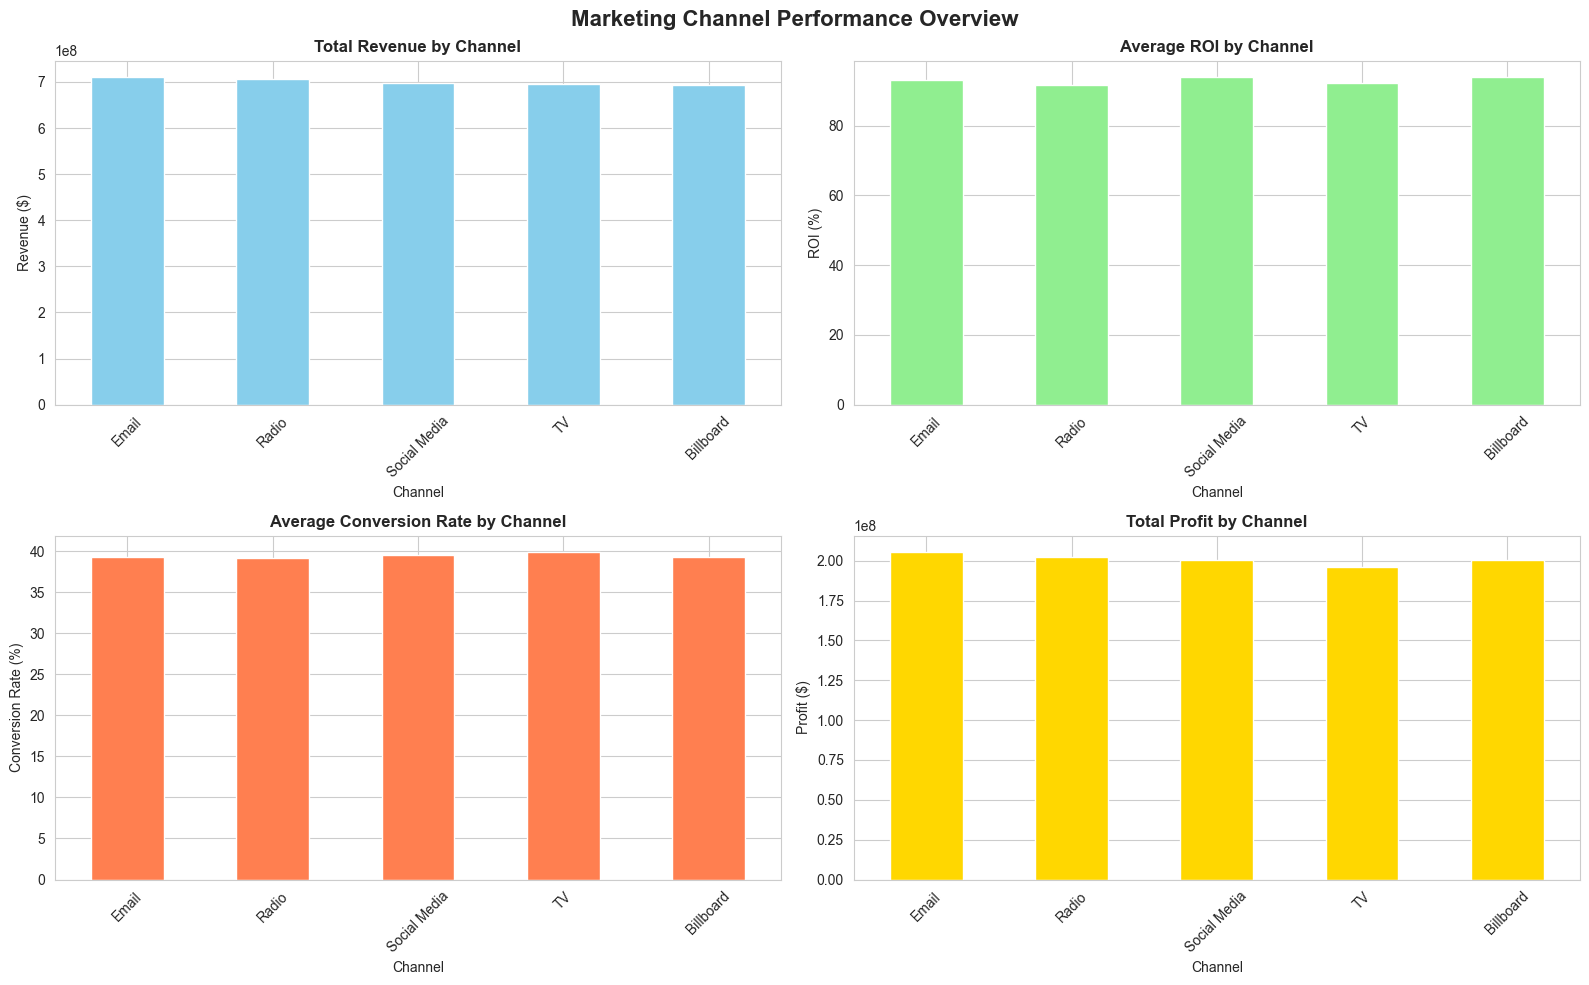

In [26]:
# Visualize channel performance
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Marketing Channel Performance Overview', fontsize=16, fontweight='bold')

# Revenue by Channel
channel_analysis['Total_Revenue'].plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Total Revenue by Channel', fontweight='bold')
axes[0, 0].set_ylabel('Revenue ($)')
axes[0, 0].set_xlabel('Channel')
axes[0, 0].tick_params(axis='x', rotation=45)

# Average ROI by Channel
channel_analysis['Avg_ROI'].plot(kind='bar', ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Average ROI by Channel', fontweight='bold')
axes[0, 1].set_ylabel('ROI (%)')
axes[0, 1].set_xlabel('Channel')
axes[0, 1].tick_params(axis='x', rotation=45)

# Conversion Rate by Channel
channel_analysis['Avg_Conversion_Rate'].plot(kind='bar', ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Average Conversion Rate by Channel', fontweight='bold')
axes[1, 0].set_ylabel('Conversion Rate (%)')
axes[1, 0].set_xlabel('Channel')
axes[1, 0].tick_params(axis='x', rotation=45)

# Total Profit by Channel
channel_analysis['Total_Profit'].plot(kind='bar', ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Total Profit by Channel', fontweight='bold')
axes[1, 1].set_ylabel('Profit ($)')
axes[1, 1].set_xlabel('Channel')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Product Performance Analysis

Which products are driving the most revenue? Let's find out!

In [27]:
# Product performance analysis
product_analysis = df.groupby('Product').agg({
    'Campaign_ID': 'count',
    'Revenue': 'sum',
    'Spend': 'sum',
    'Profit': 'sum',
    'ROI': 'mean',
    'Conversion_Rate': 'mean'
}).round(2)

product_analysis.columns = ['Total_Campaigns', 'Total_Revenue', 'Total_Spend', 
                            'Total_Profit', 'Avg_ROI', 'Avg_Conversion_Rate']
product_analysis = product_analysis.sort_values('Total_Revenue', ascending=False)

print("PRODUCT PERFORMANCE SUMMARY")
print(product_analysis)

# Identify top and bottom performers
top_product_revenue = product_analysis['Total_Revenue'].idxmax()
bottom_product_revenue = product_analysis['Total_Revenue'].idxmin()
most_profitable = product_analysis['Total_Profit'].idxmax()
best_roi_product = product_analysis['Avg_ROI'].idxmax()

print("\nPRODUCT INSIGHTS")
print(f"Top Revenue Generator: {top_product_revenue}")
print(f"  Revenue: ${product_analysis.loc[top_product_revenue, 'Total_Revenue']:,.2f}")
print(f"Most Profitable: {most_profitable}")
print(f"  Profit: ${product_analysis.loc[most_profitable, 'Total_Profit']:,.2f}")
print(f"Best ROI: {best_roi_product}")
print(f"  ROI: {product_analysis.loc[best_roi_product, 'Avg_ROI']:.2f}%")
print(f"Lowest Revenue: {bottom_product_revenue}")
print(f"  Revenue: ${product_analysis.loc[bottom_product_revenue, 'Total_Revenue']:,.2f}")

PRODUCT PERFORMANCE SUMMARY
                  Total_Campaigns  Total_Revenue  Total_Spend  Total_Profit  \
Product                                                                       
Home Appliances             10183      357861499    255000562     102860937   
Clothing                    10124      355329794    250794169     104535625   
Automotive                  10090      353393386    251618599     101774787   
Groceries                   10039      351564297    251787135      99777162   
Electronics                  9987      350499772    251676209      98823563   
Toys                         9945      349700626    248799964     100900662   
Books                        9884      347132303    246407359     100724944   
Beauty Products              9920      346933964    247933437      99000527   
Sports Equipment             9923      345426726    247081865      98344861   
Furniture                    9905      344883704    247298712      97584992   

                  Avg_R

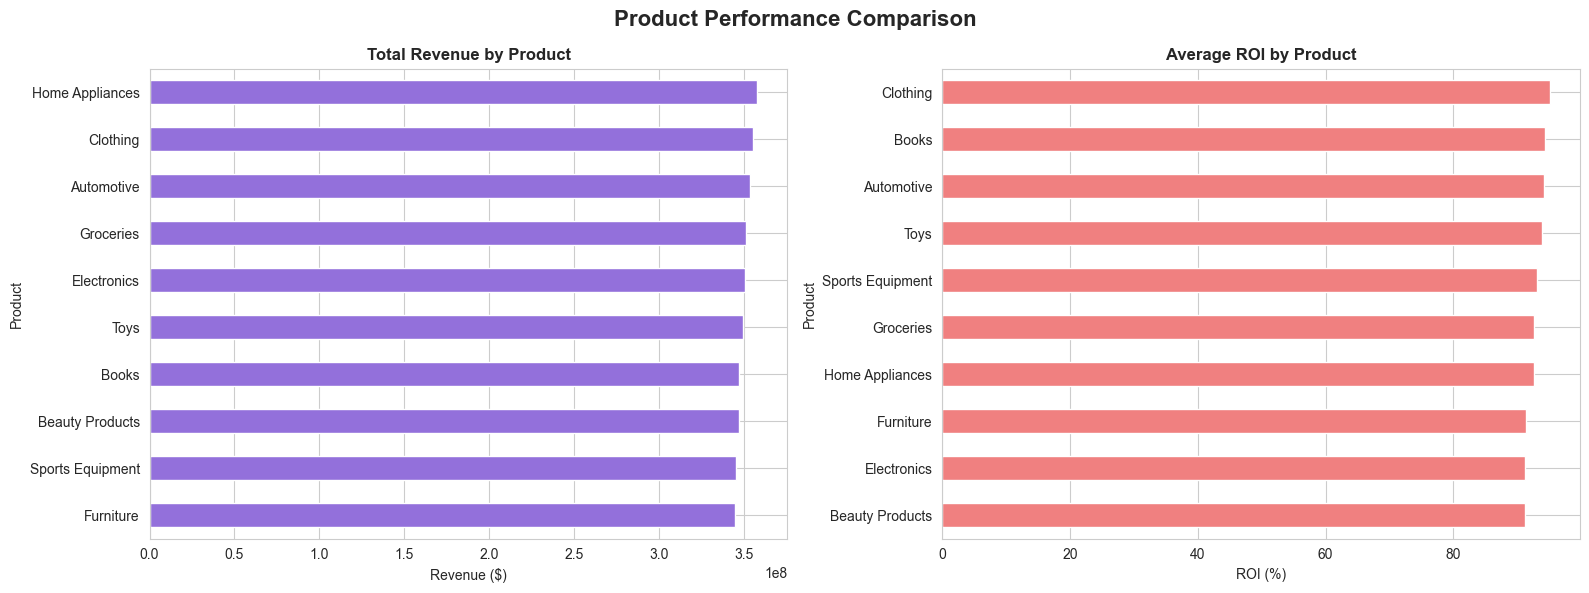

In [28]:
# Visualize product performance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Product Performance Comparison', fontsize=16, fontweight='bold')

# Revenue by Product
product_analysis['Total_Revenue'].sort_values().plot(kind='barh', ax=axes[0], color='mediumpurple')
axes[0].set_title('Total Revenue by Product', fontweight='bold')
axes[0].set_xlabel('Revenue ($)')
axes[0].set_ylabel('Product')

# ROI by Product
product_analysis['Avg_ROI'].sort_values().plot(kind='barh', ax=axes[1], color='lightcoral')
axes[1].set_title('Average ROI by Product', fontweight='bold')
axes[1].set_xlabel('ROI (%)')
axes[1].set_ylabel('Product')

plt.tight_layout()
plt.show()

## 7. Geographic Performance Analysis

Let's see which countries and cities are generating the most revenue.

In [29]:
# Country-level analysis
country_analysis = df.groupby('Country').agg({
    'Campaign_ID': 'count',
    'Revenue': 'sum',
    'Spend': 'sum',
    'Profit': 'sum',
    'Leads_Generated': 'sum',
    'Conversions': 'sum',
    'ROI': 'mean'
}).round(2)

country_analysis.columns = ['Total_Campaigns', 'Total_Revenue', 'Total_Spend', 
                            'Total_Profit', 'Total_Leads', 'Total_Conversions', 'Avg_ROI']
country_analysis = country_analysis.sort_values('Total_Revenue', ascending=False)

print("TOP 10 COUNTRIES BY REVENUE")
print(country_analysis.head(10))

# Top performing countries
top_country = country_analysis['Total_Revenue'].idxmax()
top_roi_country = country_analysis['Avg_ROI'].idxmax()

print("\nGEOGRAPHIC INSIGHTS")
print(f"Top Revenue Country: {top_country}")
print(f"  Revenue: ${country_analysis.loc[top_country, 'Total_Revenue']:,.2f}")
print(f"  Campaigns: {country_analysis.loc[top_country, 'Total_Campaigns']}")
print(f"Best ROI Country: {top_roi_country}")
print(f"  ROI: {country_analysis.loc[top_roi_country, 'Avg_ROI']:.2f}%")

TOP 10 COUNTRIES BY REVENUE
              Total_Campaigns  Total_Revenue  Total_Spend  Total_Profit  \
Country                                                                   
France                  10136      355839353    255509064     100330289   
USA                     10120      355623754    252437262     103186492   
Japan                   10046      352430281    251841498     100588783   
UK                      10033      349984881    250763913      99220968   
Brazil                   9983      349023098    250529738      98493360   
Canada                   9997      348787831    250032530      98755301   
South Africa             9946      348668484    245013682     103654802   
Germany                  9882      347756637    246038387     101718250   
Australia                9930      347609062    250263289      97345773   
India                    9927      347002690    245968648     101034042   

              Total_Leads  Total_Conversions  Avg_ROI  
Country        

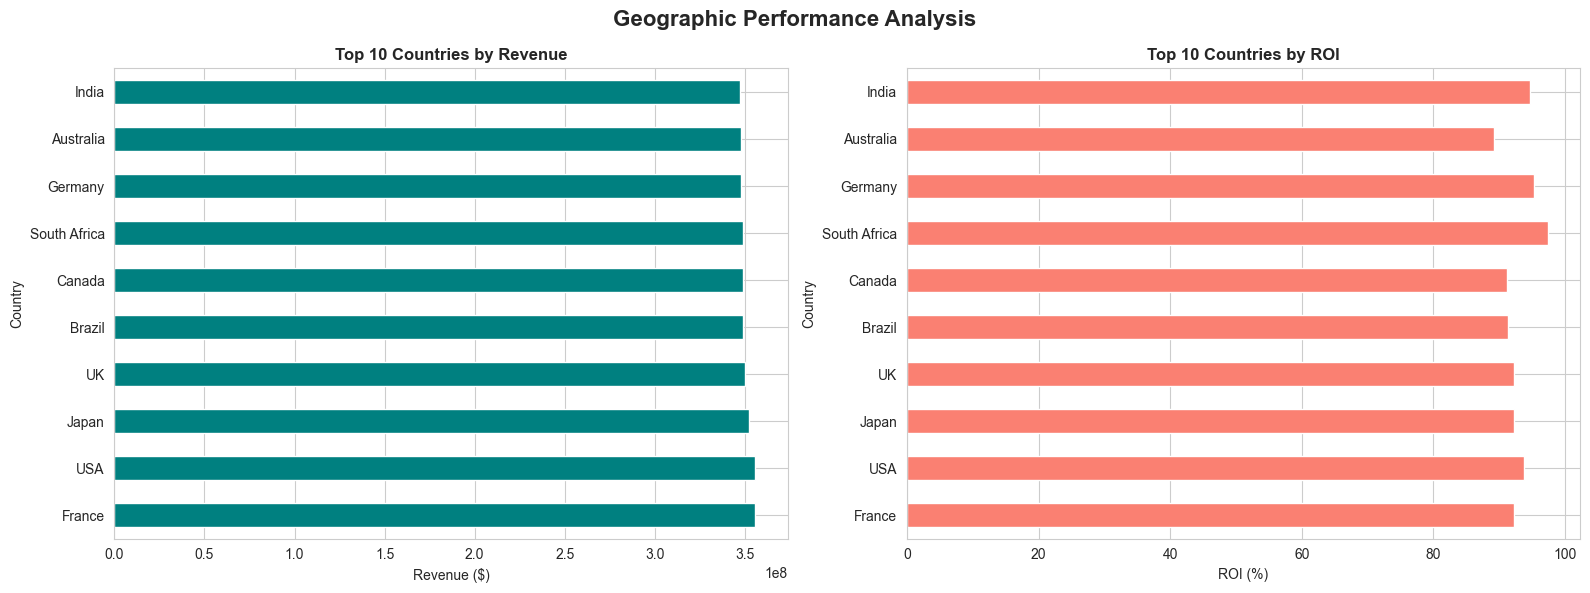

In [30]:
# Visualize top countries
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Geographic Performance Analysis', fontsize=16, fontweight='bold')

# Top 10 countries by revenue
top_10_countries = country_analysis['Total_Revenue'].head(10)
top_10_countries.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Top 10 Countries by Revenue', fontweight='bold')
axes[0].set_xlabel('Revenue ($)')
axes[0].set_ylabel('Country')

# Top 10 countries by ROI
top_10_roi = country_analysis['Avg_ROI'].head(10)
top_10_roi.plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Top 10 Countries by ROI', fontweight='bold')
axes[1].set_xlabel('ROI (%)')
axes[1].set_ylabel('Country')

plt.tight_layout()
plt.show()

## 8. Campaign Type Performance Analysis

Let's analyze which types of campaigns (e.g., Holiday Specials, Black Friday) perform best.

In [31]:
# Campaign type performance analysis
campaign_type_analysis = df.groupby('Campaign_Name').agg({
    'Campaign_ID': 'count',
    'Revenue': ['sum', 'mean'],
    'Spend': 'sum',
    'ROI': 'mean',
    'Conversion_Rate': 'mean'
}).round(2)

campaign_type_analysis.columns = ['Total_Campaigns', 'Total_Revenue', 'Avg_Revenue_Per_Campaign',
                                   'Total_Spend', 'Avg_ROI', 'Avg_Conversion_Rate']
campaign_type_analysis = campaign_type_analysis.sort_values('Total_Revenue', ascending=False)

print("CAMPAIGN TYPE PERFORMANCE")
print(campaign_type_analysis)

best_campaign_type = campaign_type_analysis['Total_Revenue'].idxmax()
best_roi_campaign = campaign_type_analysis['Avg_ROI'].idxmax()

print("\nBEST PERFORMING CAMPAIGN TYPES")
print(f"Best by Revenue: {best_campaign_type}")
print(f"  Total Revenue: ${campaign_type_analysis.loc[best_campaign_type, 'Total_Revenue']:,.2f}")
print(f"  Average ROI: {campaign_type_analysis.loc[best_campaign_type, 'Avg_ROI']:.2f}%")
print(f"Best by ROI: {best_roi_campaign}")
print(f"  ROI: {campaign_type_analysis.loc[best_roi_campaign, 'Avg_ROI']:.2f}%")

CAMPAIGN TYPE PERFORMANCE
                         Total_Campaigns  Total_Revenue  \
Campaign_Name                                             
Summer Discount Blast               8363      295466433   
Limited Time Offer                  8421      293889456   
Exclusive Launch                    8340      293614602   
Winter Clearance                    8362      293388922   
New Year Deals                      8349      292760938   
Anniversary Celebration             8348      292451781   
Back to School                      8327      292245846   
Black Friday                        8342      292092321   
Cyber Monday                        8377      292053682   
Spring Sale                         8293      289644501   
Holiday Specials                    8311      288938424   
Mega Savings                        8167      286179165   

                         Avg_Revenue_Per_Campaign  Total_Spend  Avg_ROI  \
Campaign_Name                                                           

## 9. Time-Based Analysis

Are there seasonal trends? Which months perform best? Let's find out!

In [32]:
# Yearly performance
yearly_performance = df.groupby('Year').agg({
    'Campaign_ID': 'count',
    'Revenue': 'sum',
    'Spend': 'sum',
    'Profit': 'sum',
    'ROI': 'mean'
}).round(2)

print("YEARLY PERFORMANCE")
print(yearly_performance)

# Calculate year-over-year growth
if len(yearly_performance) > 1:
    revenue_growth = yearly_performance['Revenue'].pct_change() * 100
    print("\nYear-over-Year Revenue Growth:")
    for year, growth in revenue_growth.items():
        if not pd.isna(growth):
            print(f"  {year}: {growth:+.2f}%")

# Monthly performance
monthly_performance = df.groupby('Month').agg({
    'Campaign_ID': 'count',
    'Revenue': 'sum',
    'Spend': 'sum',
    'ROI': 'mean',
    'Conversion_Rate': 'mean'
}).round(2)

print("\nMONTHLY PERFORMANCE")
print(monthly_performance)

# Best and worst months
best_month = monthly_performance['Revenue'].idxmax()
worst_month = monthly_performance['Revenue'].idxmin()

month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 
               6: 'June', 7: 'July', 8: 'August', 9: 'September', 10: 'October', 
               11: 'November', 12: 'December'}

print("\nSEASONAL INSIGHTS")
print(f"Best Performing Month: {month_names.get(best_month, best_month)}")
print(f"  Revenue: ${monthly_performance.loc[best_month, 'Revenue']:,.2f}")
print(f"Weakest Month: {month_names.get(worst_month, worst_month)}")
print(f"  Revenue: ${monthly_performance.loc[worst_month, 'Revenue']:,.2f}")

# Calculate revenue variance
revenue_variance = ((monthly_performance['Revenue'].max() - monthly_performance['Revenue'].min()) / 
                    monthly_performance['Revenue'].mean() * 100)
print(f"Revenue Variance Across Months: {revenue_variance:.2f}%") 

YEARLY PERFORMANCE
      Campaign_ID     Revenue      Spend     Profit   ROI
Year                                                     
2022        33290  1167138844  831327863  335810981 93.20
2023        33387  1174091103  834675559  339415544 93.80
2024        33323  1161496124  832394589  329101535 91.87

Year-over-Year Revenue Growth:
  2023: +0.60%
  2024: -1.07%

MONTHLY PERFORMANCE
       Campaign_ID    Revenue      Spend   ROI  Conversion_Rate
Month                                                          
1             8501  297978140  211131309 95.01            39.29
2             7667  268023040  191554601 93.04            39.14
3             8599  301304365  214173481 94.67            39.69
4             8341  291607891  206672138 94.07            39.30
5             8449  296415390  212606189 90.12            39.36
6             8266  288973507  206457257 93.79            39.42
7             8424  295152530  212986590 90.72            40.14
8             8351  293438346  2

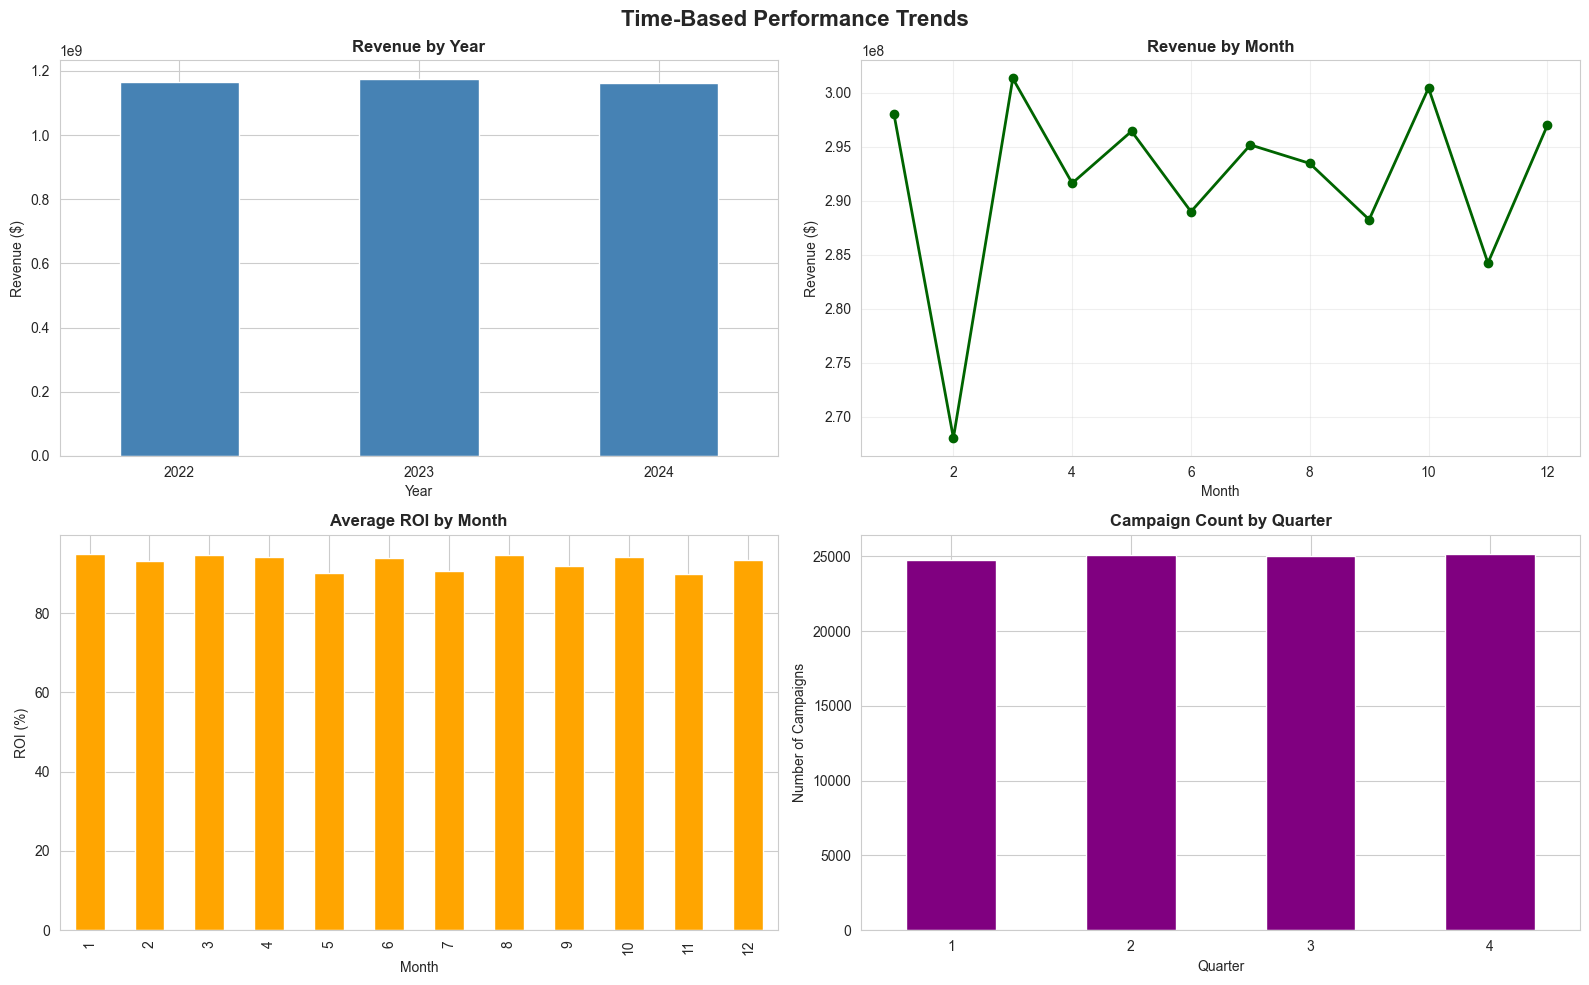

In [33]:
# Visualize time-based trends
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Time-Based Performance Trends', fontsize=16, fontweight='bold')

# Revenue by Year
yearly_performance['Revenue'].plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Revenue by Year', fontweight='bold')
axes[0, 0].set_ylabel('Revenue ($)')
axes[0, 0].set_xlabel('Year')
axes[0, 0].tick_params(axis='x', rotation=0)

# Revenue by Month
monthly_performance['Revenue'].plot(kind='line', marker='o', ax=axes[0, 1], color='darkgreen', linewidth=2)
axes[0, 1].set_title('Revenue by Month', fontweight='bold')
axes[0, 1].set_ylabel('Revenue ($)')
axes[0, 1].set_xlabel('Month')
axes[0, 1].grid(True, alpha=0.3)

# ROI by Month
monthly_performance['ROI'].plot(kind='bar', ax=axes[1, 0], color='orange')
axes[1, 0].set_title('Average ROI by Month', fontweight='bold')
axes[1, 0].set_ylabel('ROI (%)')
axes[1, 0].set_xlabel('Month')

# Campaigns by Quarter
quarterly_performance = df.groupby('Quarter')['Campaign_ID'].count()
quarterly_performance.plot(kind='bar', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Campaign Count by Quarter', fontweight='bold')
axes[1, 1].set_ylabel('Number of Campaigns')
axes[1, 1].set_xlabel('Quarter')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Budget vs Spend by Month

Let's visualize how actual spend compares to budget allocation across different months.

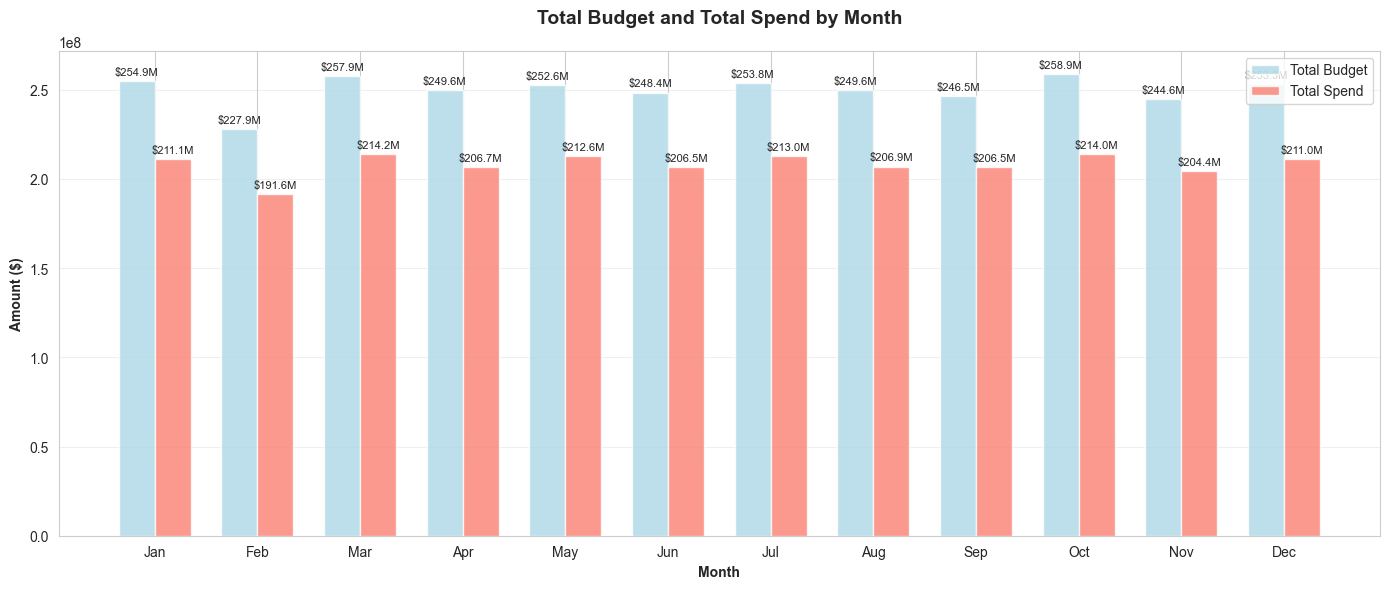


Budget vs Spend Insights:
All months stayed within budget!


In [34]:
# Budget vs Spend by Month analysis
monthly_budget_spend = df.groupby('Month').agg({
    'Budget': 'sum',
    'Spend': 'sum'
}).round(2)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(monthly_budget_spend.index))
width = 0.35

bars1 = ax.bar(x - width/2, monthly_budget_spend['Budget'], width, label='Total Budget', color='lightblue', alpha=0.8)
bars2 = ax.bar(x + width/2, monthly_budget_spend['Spend'], width, label='Total Spend', color='salmon', alpha=0.8)

ax.set_xlabel('Month', fontweight='bold')
ax.set_ylabel('Amount ($)', fontweight='bold')
ax.set_title('Total Budget and Total Spend by Month', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'${height/1e6:.1f}M',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\nBudget vs Spend Insights:")
over_budget_months = monthly_budget_spend[monthly_budget_spend['Spend'] > monthly_budget_spend['Budget']]
if len(over_budget_months) > 0:
    print(f"Months over budget: {len(over_budget_months)}")
    for month in over_budget_months.index:
        overspend = over_budget_months.loc[month, 'Spend'] - over_budget_months.loc[month, 'Budget']
        print(f"  Month {month}: Overspent by ${overspend:,.2f}")
else:
    print("All months stayed within budget!")

### Campaign Performance Scatter Analysis

Visualize the relationship between Leads, Conversions, and Revenue by Campaign Type with a trend line.

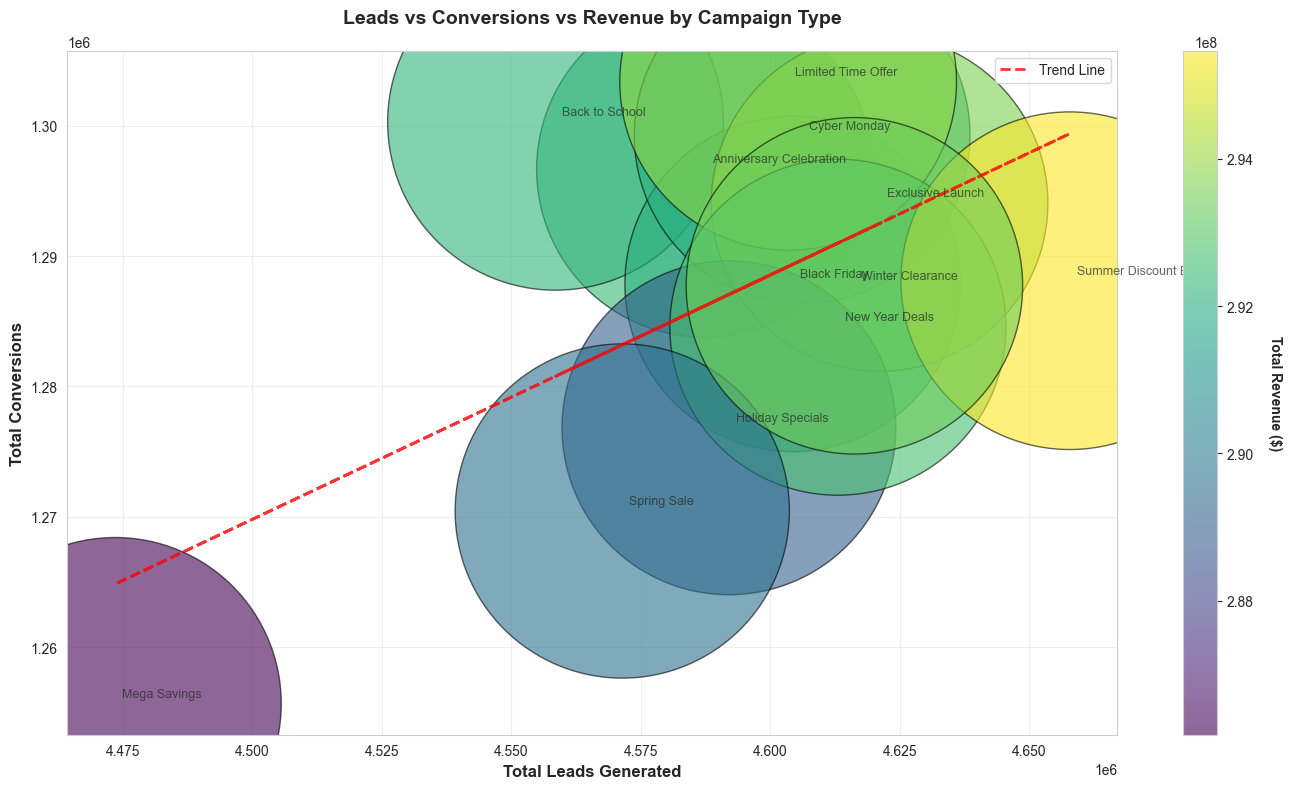


Scatter Plot Insights:
Correlation between Leads and Conversions: 0.61

Top 3 Campaign Types by Total Conversions:
  Limited Time Offer: 1,303,364 conversions (28.31% rate)
  Back to School: 1,300,262 conversions (28.52% rate)
  Cyber Monday: 1,299,236 conversions (28.21% rate)


In [35]:
# Aggregate data by Campaign Name for scatter plot
campaign_scatter_data = df.groupby('Campaign_Name').agg({
    'Leads_Generated': 'sum',
    'Conversions': 'sum',
    'Revenue': 'sum'
}).reset_index()

# Create scatter plot with trend line
fig, ax = plt.subplots(figsize=(14, 8))

# Create scatter plot with bubble size representing Revenue
scatter = ax.scatter(campaign_scatter_data['Leads_Generated'], 
                     campaign_scatter_data['Conversions'],
                     s=campaign_scatter_data['Revenue']/5000,  # Scale bubble size
                     alpha=0.6,
                     c=campaign_scatter_data['Revenue'],
                     cmap='viridis',
                     edgecolors='black',
                     linewidth=1)

# Add trend line
z = np.polyfit(campaign_scatter_data['Leads_Generated'], campaign_scatter_data['Conversions'], 1)
p = np.poly1d(z)
ax.plot(campaign_scatter_data['Leads_Generated'], 
        p(campaign_scatter_data['Leads_Generated']), 
        "r--", linewidth=2, alpha=0.8, label='Trend Line')

# Formatting
ax.set_xlabel('Total Leads Generated', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Conversions', fontsize=12, fontweight='bold')
ax.set_title('Leads vs Conversions vs Revenue by Campaign Type', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Total Revenue ($)', rotation=270, labelpad=20, fontweight='bold')

# Add campaign name labels
for idx, row in campaign_scatter_data.iterrows():
    ax.annotate(row['Campaign_Name'], 
                (row['Leads_Generated'], row['Conversions']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, alpha=0.7)

ax.legend()
plt.tight_layout()
plt.show()

print("\nScatter Plot Insights:")
print(f"Correlation between Leads and Conversions: {campaign_scatter_data['Leads_Generated'].corr(campaign_scatter_data['Conversions']):.2f}")
print(f"\nTop 3 Campaign Types by Total Conversions:")
top_campaigns = campaign_scatter_data.nlargest(3, 'Conversions')
for idx, row in top_campaigns.iterrows():
    conversion_rate = (row['Conversions'] / row['Leads_Generated'] * 100)
    print(f"  {row['Campaign_Name']}: {row['Conversions']:,} conversions ({conversion_rate:.2f}% rate)")

## 10. Correlation Analysis

Let's understand which metrics are related to each other and what drives revenue.

In [36]:
# Select numerical columns for correlation analysis
correlation_cols = ['Budget', 'Spend', 'Revenue', 'Profit', 'Leads_Generated', 
                    'Conversions', 'ROI', 'Conversion_Rate', 'Campaign_Duration_Days']

correlation_matrix = df[correlation_cols].corr().round(2)

print("CORRELATION MATRIX")
print(correlation_matrix)

# Find strongest correlations with Revenue
revenue_correlations = correlation_matrix['Revenue'].sort_values(ascending=False)
print("\nCORRELATIONS WITH REVENUE (Strongest to Weakest)")
for metric, corr in revenue_correlations.items():
    if metric != 'Revenue':
        strength = "Strong" if abs(corr) > 0.7 else "Moderate" if abs(corr) > 0.4 else "Weak"
        print(f"  {metric}: {corr:.2f} ({strength})")

CORRELATION MATRIX
                        Budget  Spend  Revenue  Profit  Leads_Generated  \
Budget                    1.00  -0.00     0.01    0.01             0.00   
Spend                    -0.00   1.00    -0.00   -0.63             0.00   
Revenue                   0.01  -0.00     1.00    0.78            -0.00   
Profit                    0.01  -0.63     0.78    1.00            -0.00   
Leads_Generated           0.00   0.00    -0.00   -0.00             1.00   
Conversions               0.00   0.00    -0.00   -0.00            -0.00   
ROI                       0.01  -0.69     0.48    0.81             0.00   
Conversion_Rate           0.00   0.00    -0.00   -0.00            -0.62   
Campaign_Duration_Days    0.00  -0.01    -0.00    0.00             0.00   

                        Conversions   ROI  Conversion_Rate  \
Budget                         0.00  0.01             0.00   
Spend                          0.00 -0.69             0.00   
Revenue                       -0.00  0.48   

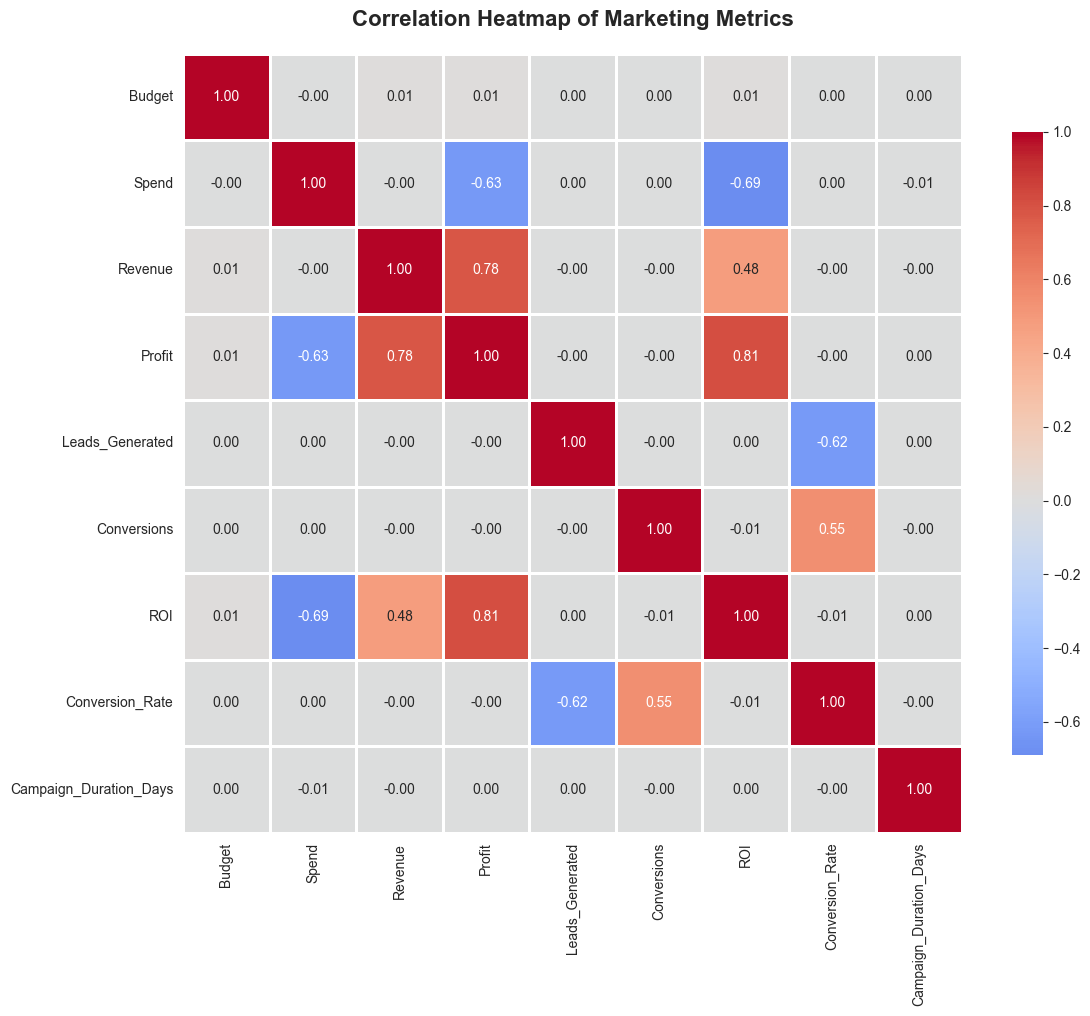

In [37]:
# Visualize correlation matrix with heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Correlation Heatmap of Marketing Metrics', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 11. Budget Efficiency Analysis

How efficiently are we utilizing our budgets? Are campaigns staying within budget?

In [38]:
# Budget utilization analysis
overspent_summary = df.groupby('Is_Overspent').agg({
    'Campaign_ID': 'count',
    'Revenue': ['sum', 'mean'],
    'Spend': 'sum',
    'Budget': 'sum',
    'ROI': 'mean'
}).round(2)

overspent_summary.columns = ['Count', 'Total_Revenue', 'Avg_Revenue', 'Total_Spend', 'Total_Budget', 'Avg_ROI']

print("BUDGET MANAGEMENT ANALYSIS")
print("\nOverspent vs Within Budget Comparison:")
print(overspent_summary)

# Calculate overspent amount
overspent_df = df[df['Is_Overspent']]
total_overspent_amount = overspent_df['Spend'].sum() - overspent_df['Budget'].sum()

print(f"\nTotal Overspent Amount: ${total_overspent_amount:,.2f}")
print(f"Average Overspend per Campaign: ${total_overspent_amount / len(overspent_df):,.2f}")

# Budget utilization distribution
print("\nBUDGET UTILIZATION DISTRIBUTION")
under_50 = (df['Budget_Utilization'] < 50).sum()
between_50_80 = ((df['Budget_Utilization'] >= 50) & (df['Budget_Utilization'] < 80)).sum()
between_80_100 = ((df['Budget_Utilization'] >= 80) & (df['Budget_Utilization'] <= 100)).sum()
over_100 = (df['Budget_Utilization'] > 100).sum()

print(f"Under 50% utilized: {under_50:,} campaigns ({under_50/len(df)*100:.2f}%)")
print(f"50-80% utilized: {between_50_80:,} campaigns ({between_50_80/len(df)*100:.2f}%)")
print(f"80-100% utilized (Optimal): {between_80_100:,} campaigns ({between_80_100/len(df)*100:.2f}%)")
print(f"Over 100% utilized: {over_100:,} campaigns ({over_100/len(df)*100:.2f}%)")

BUDGET MANAGEMENT ANALYSIS

Overspent vs Within Budget Comparison:
              Count  Total_Revenue  Avg_Revenue  Total_Spend  Total_Budget  \
Is_Overspent                                                                 
False         61656     2164794379     35110.85   1220419423    2167889131   
True          38344     1337931692     34892.86   1277978588     830172369   

              Avg_ROI  
Is_Overspent           
False          142.30  
True            13.62  

Total Overspent Amount: $447,806,219.00
Average Overspend per Campaign: $11,678.65

BUDGET UTILIZATION DISTRIBUTION
Under 50% utilized: 25,053 campaigns (25.05%)
50-80% utilized: 22,423 campaigns (22.42%)
80-100% utilized (Optimal): 14,180 campaigns (14.18%)
Over 100% utilized: 38,344 campaigns (38.34%)


## 12. Advanced Insights & Performance Tiers

Let's segment campaigns by performance and find the best combinations.

In [39]:
# Create ROI performance tiers
df['ROI_Tier'] = pd.cut(df['ROI'], 
                        bins=[-float('inf'), 0, 20, 40, float('inf')],
                        labels=['Poor (Below 0%)', 'Fair (0-20%)', 'Good (20-40%)', 'Excellent (40%+)'])

roi_tier_summary = df.groupby('ROI_Tier').agg({
    'Campaign_ID': 'count',
    'Revenue': 'sum',
    'ROI': 'mean',
    'Conversion_Rate': 'mean'
}).round(2)

roi_tier_summary.columns = ['Campaign_Count', 'Total_Revenue', 'Avg_ROI', 'Avg_Conversion_Rate']

print("CAMPAIGN PERFORMANCE TIERS")
print(roi_tier_summary)

# Best Channel + Product combinations
print("\nTOP 15 CHANNEL + PRODUCT COMBINATIONS (by Revenue)")

best_combos = df.groupby(['Channel', 'Product']).agg({
    'Campaign_ID': 'count',
    'Revenue': 'sum',
    'ROI': 'mean',
    'Conversion_Rate': 'mean'
}).round(2)

best_combos.columns = ['Campaign_Count', 'Total_Revenue', 'Avg_ROI', 'Avg_Conversion_Rate']
best_combos = best_combos.sort_values('Total_Revenue', ascending=False).head(15)

print(best_combos)

# Campaign duration impact
duration_bins = [0, 7, 14, 21, 31]
duration_labels = ['1-7 days', '8-14 days', '15-21 days', '22-30 days']
df['Duration_Category'] = pd.cut(df['Campaign_Duration_Days'], bins=duration_bins, labels=duration_labels)

duration_impact = df.groupby('Duration_Category').agg({
    'Campaign_ID': 'count',
    'Revenue': ['sum', 'mean'],
    'ROI': 'mean',
    'Conversion_Rate': 'mean'
}).round(2)

duration_impact.columns = ['Campaign_Count', 'Total_Revenue', 'Avg_Revenue', 'Avg_ROI', 'Avg_Conversion_Rate']

print("\nCAMPAIGN DURATION IMPACT")
print(duration_impact)

optimal_duration = duration_impact['Avg_ROI'].idxmax()
print(f"\nOptimal Duration: {optimal_duration} (Best Average ROI)")

CAMPAIGN PERFORMANCE TIERS
                  Campaign_Count  Total_Revenue  Avg_ROI  Avg_Conversion_Rate
ROI_Tier                                                                     
Poor (Below 0%)            30598      665375351   -33.50                39.44
Fair (0-20%)                9764      333319978    10.02                39.90
Good (20-40%)               9633      381308370    29.99                40.07
Excellent (40%+)           50005     2122722372   198.67                39.25

TOP 15 CHANNEL + PRODUCT COMBINATIONS (by Revenue)
                              Campaign_Count  Total_Revenue  Avg_ROI  \
Channel      Product                                                   
Email        Clothing                   2096       74183663    95.84   
TV           Home Appliances            2042       72961558    95.52   
Email        Groceries                  2089       72953051    90.55   
Radio        Clothing                   2090       72833723    88.35   
             Toys    

## 13. Detailed Campaign Performance Table

View individual campaign details with all key metrics - similar to the dashboard's bottom table.

In [40]:
# Create detailed campaign table with key metrics
campaign_table = df[['Campaign_ID', 'Campaign_Name', 'Country', 'City', 'Product', 
                     'Channel', 'Start_Date', 'Budget', 'Spend', 'Revenue', 
                     'Leads_Generated', 'Conversions', 'ROI', 'Conversion_Rate', 
                     'Budget_Utilization', 'Profit']].copy()

# Format dates
campaign_table['Start_Date'] = campaign_table['Start_Date'].dt.strftime('%Y-%m-%d')

# Sort by Revenue (descending) to show top performers first
campaign_table_sorted = campaign_table.sort_values('Revenue', ascending=False)

print("DETAILED CAMPAIGN PERFORMANCE TABLE (Top 20 Campaigns by Revenue)")
print("\nShowing top performers with all key metrics:\n")

# Display top 20 campaigns
top_20 = campaign_table_sorted.head(20)
print(top_20.to_string(index=False))

print("\nTABLE STATISTICS")

# Summary statistics for the table
print(f"\nTotal Campaigns in Dataset: {len(campaign_table):,}")
print(f"Date Range: {df['Start_Date'].min().strftime('%Y-%m-%d')} to {df['End_Date'].max().strftime('%Y-%m-%d')}")

print("\nTop 5 Campaigns by Revenue:")
for idx, row in campaign_table_sorted.head(5).iterrows():
    print(f"  {row['Campaign_ID']}: {row['Campaign_Name']} - ${row['Revenue']:,.2f} ({row['Channel']} in {row['Country']})")

print("\nTop 5 Campaigns by ROI:")
top_roi = campaign_table.nlargest(5, 'ROI')
for idx, row in top_roi.iterrows():
    print(f"  {row['Campaign_ID']}: {row['Campaign_Name']} - {row['ROI']:.2f}% ROI ({row['Product']})")

print("\nTop 5 Campaigns by Conversion Rate:")
top_conv = campaign_table.nlargest(5, 'Conversion_Rate')
for idx, row in top_conv.iterrows():
    print(f"  {row['Campaign_ID']}: {row['Campaign_Name']} - {row['Conversion_Rate']:.2f}% ({row['Conversions']:,} conversions)")

DETAILED CAMPAIGN PERFORMANCE TABLE (Top 20 Campaigns by Revenue)

Showing top performers with all key metrics:

Campaign_ID           Campaign_Name      Country           City          Product      Channel Start_Date  Budget  Spend  Revenue  Leads_Generated  Conversions    ROI  Conversion_Rate  Budget_Utilization  Profit
  CAMP98013          Back to School       Canada        Calgary             Toys           TV 2022-12-09   29811  42966    59999              495          271  39.64            54.75              144.13   17033
  CAMP50190          New Year Deals      Germany      Stuttgart         Clothing           TV 2023-09-03   49724  41306    59998              378          180  45.25            47.62               83.07   18692
  CAMP89942        Exclusive Launch       Canada        Toronto        Furniture    Billboard 2024-02-14   48199  41539    59998              182          275  44.44           151.10               86.18   18459
  CAMP21522            Cyber Monday       C

In [41]:
# Export full campaign table to CSV for detailed analysis
output_filename = 'detailed_campaign_analysis_table.csv'
campaign_table_sorted.to_csv(output_filename, index=False)
print(f"Full detailed campaign table exported to: {output_filename}")
print(f"Contains all {len(campaign_table_sorted):,} campaigns with complete metrics")
print("You can open this file in Excel or import it back into Power BI for further analysis!")

Full detailed campaign table exported to: detailed_campaign_analysis_table.csv
Contains all 100,000 campaigns with complete metrics
You can open this file in Excel or import it back into Power BI for further analysis!


### Filter Campaigns (Interactive Analysis)

You can filter campaigns by various criteria to match dashboard filters:

In [42]:
# Filter campaigns like the dashboard (e.g., November 2023)
print("FILTERED VIEW: November 2023 Campaigns (Matching Dashboard)")

# Filter for November 2023
filtered_campaigns = df[(df['Year'] == 2023) & (df['Month'] == 11)].copy()

# Select key columns
filtered_table = filtered_campaigns[['Campaign_ID', 'Campaign_Name', 'Country', 'Product', 
                                     'Channel', 'Budget', 'Spend', 'Revenue', 'ROI', 
                                     'Conversions', 'Conversion_Rate']].sort_values('Revenue', ascending=False)

print(f"\nTotal Campaigns in Nov 2023: {len(filtered_table):,}")
print(f"Total Revenue: ${filtered_campaigns['Revenue'].sum()/1_000_000:.2f}M")
print(f"Total Spend: ${filtered_campaigns['Spend'].sum()/1_000_000:.2f}M")
print(f"Average ROI: {filtered_campaigns['ROI'].mean():.2f}%")

print(f"\nTop 15 Campaigns from November 2023:\n")
print(filtered_table.head(15).to_string(index=False))

print("\nTIP: You can modify the filter criteria above to match any dashboard selection!")
print("Examples: df[df['Country'] == 'USA'] or df[df['Channel'] == 'Email']")

FILTERED VIEW: November 2023 Campaigns (Matching Dashboard)

Total Campaigns in Nov 2023: 2,674
Total Revenue: $95.15M
Total Spend: $67.14M
Average ROI: 93.89%

Top 15 Campaigns from November 2023:

Campaign_ID           Campaign_Name      Country         Product      Channel  Budget  Spend  Revenue    ROI  Conversions  Conversion_Rate
  CAMP94035            Mega Savings       Brazil Beauty Products    Billboard   23706  42807    59990  40.14          140            62.50
  CAMP87666            Cyber Monday South Africa           Books           TV   40904  18611    59922 221.97           63            25.71
  CAMP86597          Back to School    Australia Beauty Products           TV   28946  42193    59918  42.01          180            20.88
  CAMP05519          New Year Deals        India     Electronics        Email   42982  28502    59903 110.17          284            60.17
  CAMP45838            Mega Savings        Japan       Groceries    Billboard   45361  43693    59900  37.

## 14. Key Findings & Actionable Recommendations

Based on our comprehensive analysis, here are the key insights and recommendations for optimizing future campaigns.

In [43]:
print("KEY FINDINGS & RECOMMENDATIONS")
print("\nKEY FINDINGS")

print("\n1. OVERALL PERFORMANCE:")
print(f"  Generated ${total_revenue:,.2f} in revenue with ${total_spend:,.2f} spend")
print(f"  Average ROI of {avg_roi:.2f}% indicates healthy campaign performance")
print(f"  Total profit: ${total_profit:,.2f}")
print(f"  Conversion rate of {avg_conversion_rate:.2f}% from {total_leads:,} leads")

print("\n2. CHANNEL EFFECTIVENESS:")
print(f"  {best_channel_revenue} generates highest revenue: ${channel_analysis.loc[best_channel_revenue, 'Total_Revenue']:,.2f}")
print(f"  {best_channel_roi} provides best ROI: {channel_analysis.loc[best_channel_roi, 'Avg_ROI']:.2f}%")
print(f"  {best_channel_conversion} has highest conversion rate: {channel_analysis.loc[best_channel_conversion, 'Avg_Conversion_Rate']:.2f}%")

print("\n3. PRODUCT PERFORMANCE:")
print(f"  {top_product_revenue} is the top revenue generator")
print(f"  {most_profitable} delivers highest profit margins")
print(f"  Significant variation in product performance suggests optimization opportunity")

print("\n4. GEOGRAPHIC INSIGHTS:")
print(f"  {top_country} leads in revenue generation")
print(f"  {top_roi_country} shows best ROI potential")
print(f"  Geographic expansion opportunities exist in underperforming markets")

print("\n5. TEMPORAL PATTERNS:")
print(f"  {month_names.get(best_month, best_month)} is historically the best performing month")
print(f"  Clear seasonal patterns exist that can be leveraged")
print(f"  {optimal_duration} campaigns show optimal ROI")

print("\n6. BUDGET MANAGEMENT:")
print(f"  {overspent_campaigns:,} campaigns ({overspent_campaigns/len(df)*100:.2f}%) exceeded budget")
print(f"  Total overspent amount: ${total_overspent_amount:,.2f}")
print(f"  Budget forecasting and monitoring needs improvement")

print("\nACTIONABLE RECOMMENDATIONS")

print("\n1. OPTIMIZE CHANNEL MIX:")
print(f"  Increase investment in {best_channel_roi} (highest ROI: {channel_analysis.loc[best_channel_roi, 'Avg_ROI']:.2f}%)")
print(f"  Maintain strong presence in {best_channel_revenue} (top revenue driver)")
print("  Test budget reallocation from underperforming channels")
print("  Implement A/B testing across channels to optimize messaging")

print("\n2. PRODUCT STRATEGY:")
print(f"  Scale campaigns for {top_product_revenue} (proven top performer)")
print(f"  Analyze and replicate success factors of {most_profitable}")
print(f"  Review marketing approach for {bottom_product_revenue}")
print("  Consider bundling strategies for lower-performing products")

print("\n3. GEOGRAPHIC EXPANSION:")
print(f"  Expand successful strategies from {top_country} to other markets")
print("  Conduct market research in low-performing countries")
print("  Implement localized campaigns for specific regions")
print("  Focus on high-ROI countries for maximum efficiency")

print("\n4. IMPROVE CONVERSION RATES:")
print(f"  Current average: {avg_conversion_rate:.2f}% - set target of 35%+")
print(f"  Study and replicate tactics from {best_channel_conversion} channel")
print("  Implement A/B testing for landing pages and ad creatives")
print("  Enhance lead nurturing processes")
print("  Invest in CRO (Conversion Rate Optimization) tools")

print("\n5. BUDGET OPTIMIZATION:")
print(f"  Reduce overspending: {overspent_campaigns:,} campaigns need attention")
print(f"  Save potential ${total_overspent_amount:,.2f} through better budget management")
print("  Implement real-time budget monitoring systems")
print("  Establish approval workflows for budget increases")
print("  Create budget templates based on campaign type and channel")

print("\n6. TIMING OPTIMIZATION:")
print(f"  Focus major campaigns in {month_names.get(best_month, best_month)} (historically best month)")
print("  Plan promotional campaigns around high-performing seasons")
print("  Reduce spend during consistently low-performing periods")
print(f"  Optimize campaign duration to {optimal_duration}")

print("\n7. LEVERAGE BEST COMBINATIONS:")
print("  Prioritize top channel + product combinations from analysis")
print("  Allocate more budget to proven winning combinations")
print("  Test underperforming combinations with different messaging")

print("\n8. PERFORMANCE MONITORING:")
print("  Set up real-time dashboard for KPI tracking")
print("  Implement weekly performance reviews")
print("  Create alerts for campaigns underperforming or overspending")
print("  Schedule monthly deep-dive analysis sessions")

print("\n9. DATA-DRIVEN DECISION MAKING:")
print("  Use predictive analytics for campaign planning")
print("  Implement machine learning for budget optimization")
print("  Build customer segmentation models")
print("  Create ROI prediction models before campaign launch")

print("\n10. QUICK WINS:")
print("  Immediately reduce budget for poor-performing campaigns")
print("  Reallocate saved budget to high-ROI campaigns")
print("  Standardize successful campaign templates")
print("  Share best practices across marketing team")
print("\nANALYSIS COMPLETE")
print("\nExpected Impact of Implementing Recommendations:")
print(f"  Potential ROI increase: +5-10 percentage points")
print(f"  Budget savings from overspend reduction: ~${total_overspent_amount:,.2f}")
print(f"  Conversion rate improvement potential: +3-5 percentage points")
print(f"  Revenue growth potential: 15-20% year-over-year")

print("\nNext Steps:")
print("  1. Share this analysis with marketing leadership team")
print("  2. Prioritize top 3 recommendations for immediate implementation")
print("  3. Set up quarterly performance review meetings")
print("  4. Create action plan with owners and timelines")
print("  5. Implement tracking mechanisms for recommendation impact")

print("\nDASHBOARD KPIs")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Avg ROI: {avg_roi:.2f}%")
print(f"Best Channel: {best_channel_revenue}")
print(f"Conversion Rate: {avg_conversion_rate:.2f}%")

print("\nThank you for using this Marketing Campaign Analysis!")

KEY FINDINGS & RECOMMENDATIONS

KEY FINDINGS

1. OVERALL PERFORMANCE:
  Generated $3,502,726,071.00 in revenue with $2,498,398,011.00 spend
  Average ROI of 92.96% indicates healthy campaign performance
  Total profit: $1,004,328,060.00
  Conversion rate of 39.45% from 55,104,901 leads

2. CHANNEL EFFECTIVENESS:
  Email generates highest revenue: $710,919,613.00
  Billboard provides best ROI: 93.97%
  TV has highest conversion rate: 39.93%

3. PRODUCT PERFORMANCE:
  Home Appliances is the top revenue generator
  Clothing delivers highest profit margins
  Significant variation in product performance suggests optimization opportunity

4. GEOGRAPHIC INSIGHTS:
  France leads in revenue generation
  South Africa shows best ROI potential
  Geographic expansion opportunities exist in underperforming markets

5. TEMPORAL PATTERNS:
  March is historically the best performing month
  Clear seasonal patterns exist that can be leveraged
  22-30 days campaigns show optimal ROI

6. BUDGET MANAGEMENT

## Conclusion

Congratulations! You've completed a comprehensive exploratory data analysis of the marketing campaign dataset.

### What We Learned:
- How to load and explore data
- Feature engineering and creating calculated metrics
- Channel, product, and geographic performance analysis
- Time-based trends and seasonal patterns
- Correlation analysis between metrics
- Budget efficiency evaluation
- Advanced segmentation and insights
- Data-driven recommendations

### Skills Practiced:
- Data manipulation with Pandas  
- Statistical analysis with NumPy  
- Data visualization with Matplotlib & Seaborn  
- Business intelligence and insight generation  
- Strategic recommendation development  

### Keep Learning:
- Experiment with additional visualizations
- Try different segmentation approaches
- Build predictive models for campaign performance
- Create an automated reporting pipeline
- Develop interactive dashboards with Plotly or Dash

---

**Remember:** Data analysis is an iterative process. Always question your assumptions, validate your findings, and communicate insights clearly to stakeholders!